Primero importamos las librerias a usar

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

Leemos el dataset y analisamos al dataset

In [2]:
df = pd.read_csv("data/supermarket.csv")

Ver los cabezales del dataset

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


Ver las columnas

In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

Ver toda la informacion del dataset

In [5]:
df.info

<bound method DataFrame.info of       Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
1          2  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
2          3  CA-2017-138688  12/06/2017  16/06/2017    Second Class   
3          4  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
4          5  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
...      ...             ...         ...         ...             ...   
9795    9796  CA-2017-125920  21/05/2017  28/05/2017  Standard Class   
9796    9797  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9797    9798  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9798    9799  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9799    9800  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520      

Descripcion del dataset

In [6]:
df.describe

<bound method NDFrame.describe of       Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
1          2  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
2          3  CA-2017-138688  12/06/2017  16/06/2017    Second Class   
3          4  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
4          5  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
...      ...             ...         ...         ...             ...   
9795    9796  CA-2017-125920  21/05/2017  28/05/2017  Standard Class   
9796    9797  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9797    9798  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9798    9799  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9799    9800  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520    

Vemos los valores nulos 

In [7]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

importamos la libreria missingno y msno para la graficacion de los valores nulos y la relacion que tienen entre ellos

In [8]:
import missingno as msno

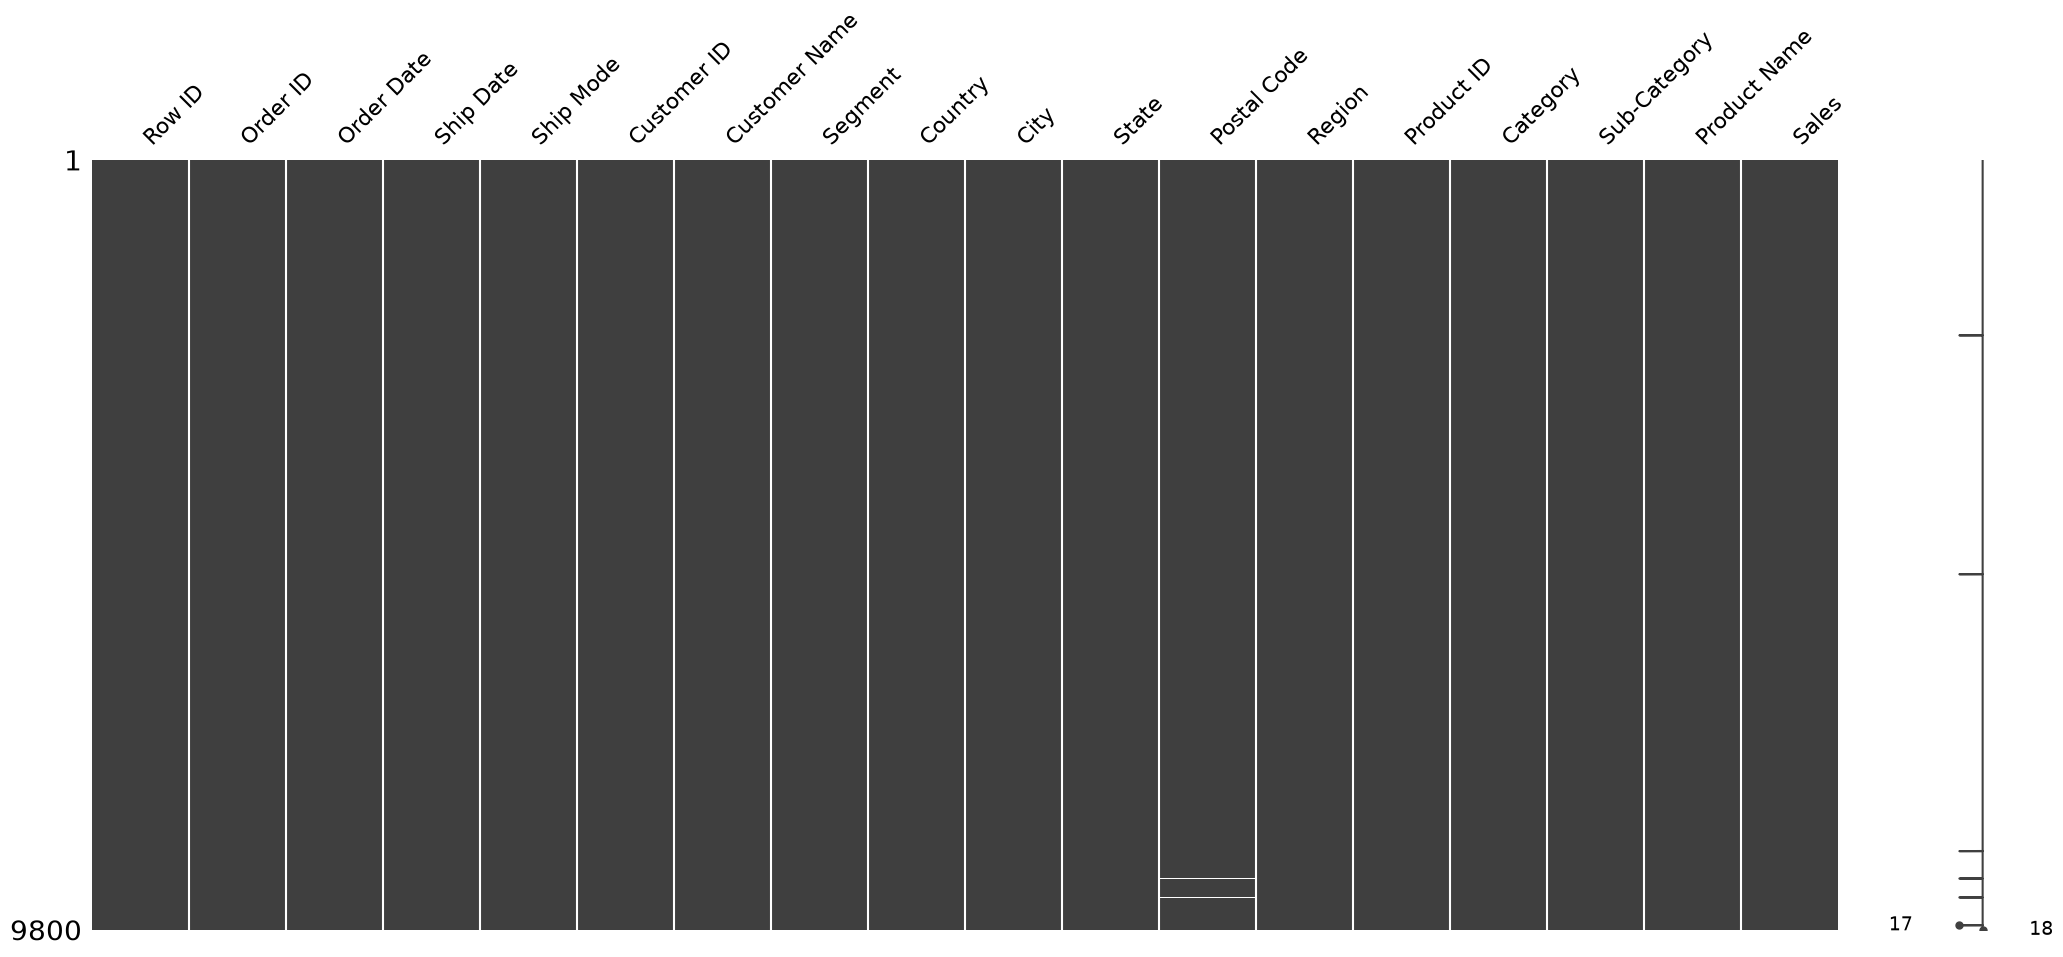

In [15]:
msno.matrix(df)
plt.show()


Analizamos la variable de estudio del dataset en esta caso la variable es SALES que nos dice las ventas que se han realizado en el supermercado

In [19]:
df["Sales"].fillna(
    df["Sales"].median(),
    inplace=True
)

C:\Users\gaell\AppData\Local\Temp\ipykernel_16472\1104636420.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Sales"].fillna(


0       261.9600
1       731.9400
2        14.6200
3       957.5775
4        22.3680
          ...   
9795      3.7980
9796     10.3680
9797    235.1880
9798     26.3760
9799     10.3840
Name: Sales, Length: 9800, dtype: float64

Estudiaremos el atributo codigo postal

In [21]:
df["Postal Code"].fillna(
    df["Postal Code"].mode()[0],
    inplace=True
)

C:\Users\gaell\AppData\Local\Temp\ipykernel_16472\645944901.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Postal Code"].fillna(


0       42420.0
1       42420.0
2       90036.0
3       33311.0
4       33311.0
         ...   
9795    60610.0
9796    43615.0
9797    43615.0
9798    43615.0
9799    43615.0
Name: Postal Code, Length: 9800, dtype: float64

Verificamos los datos vacios de ambas intancias

In [22]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Esto regresa la columna donde los clientes son del segmento Consumer

In [28]:
df[df["Segment"] == "Consumer"]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9790,9791,CA-2018-144491,27/03/2018,01/04/2018,Standard Class,CJ-12010,Caroline Jumper,Consumer,United States,Houston,Texas,77070.0,Central,FUR-CH-10001714,Furniture,Chairs,"Global Leather & Oak Executive Chair, Burgundy",211.2460
9791,9792,CA-2015-127166,21/05/2015,23/05/2015,Second Class,KH-16360,Katherine Hughes,Consumer,United States,Houston,Texas,77070.0,Central,OFF-EN-10003134,Office Supplies,Envelopes,Staple envelope,56.0640
9792,9793,CA-2015-127166,21/05/2015,23/05/2015,Second Class,KH-16360,Katherine Hughes,Consumer,United States,Houston,Texas,77070.0,Central,FUR-CH-10003396,Furniture,Chairs,Global Deluxe Steno Chair,107.7720
9793,9794,CA-2015-127166,21/05/2015,23/05/2015,Second Class,KH-16360,Katherine Hughes,Consumer,United States,Houston,Texas,77070.0,Central,OFF-PA-10001560,Office Supplies,Paper,"Adams Telephone Message Books, 5 1/4” x 11”",4.8320


Crear una columna binaria

In [29]:
df["Venta_Alta"] = (df["Sales"] > df["Sales"].median()).astype(int)

In [31]:
df[df["Venta_Alta"] == 1]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Venta_Alta
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,1
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,1
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,1
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,1
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9788,9789,CA-2018-144491,27/03/2018,01/04/2018,Standard Class,CJ-12010,Caroline Jumper,Consumer,United States,Houston,Texas,77070.0,Central,FUR-CH-10004063,Furniture,Chairs,Global Deluxe High-Back Manager's Chair,600.5580,1
9790,9791,CA-2018-144491,27/03/2018,01/04/2018,Standard Class,CJ-12010,Caroline Jumper,Consumer,United States,Houston,Texas,77070.0,Central,FUR-CH-10001714,Furniture,Chairs,"Global Leather & Oak Executive Chair, Burgundy",211.2460,1
9791,9792,CA-2015-127166,21/05/2015,23/05/2015,Second Class,KH-16360,Katherine Hughes,Consumer,United States,Houston,Texas,77070.0,Central,OFF-EN-10003134,Office Supplies,Envelopes,Staple envelope,56.0640,1
9792,9793,CA-2015-127166,21/05/2015,23/05/2015,Second Class,KH-16360,Katherine Hughes,Consumer,United States,Houston,Texas,77070.0,Central,FUR-CH-10003396,Furniture,Chairs,Global Deluxe Steno Chair,107.7720,1


Recapitulamos un total de 50 muestras aleatorias de toda nuestra data set

In [32]:
muestra = df.sample(
    n=50,
    random_state=42
)

muestra

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Venta_Alta
532,533,US-2018-129441,07/09/2018,11/09/2018,Standard Class,JC-15340,Jasper Cacioppo,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10000448,Furniture,Furnishings,Tenex Chairmats For Use With Carpeted Floors,47.940,0
872,873,CA-2015-148488,10/12/2015,15/12/2015,Standard Class,SM-20005,Sally Matthias,Consumer,United States,New York City,New York,10009.0,East,OFF-PA-10004470,Office Supplies,Paper,"Adams Write n' Stick Phone Message Book, 11"" X...",11.360,0
1149,1150,CA-2016-112452,04/04/2016,04/04/2016,Same Day,NC-18340,Nat Carroll,Consumer,United States,Lansing,Michigan,48911.0,Central,TEC-PH-10000307,Technology,Phones,Shocksock Galaxy S4 Armband,10.950,0
2287,2288,US-2018-112928,01/06/2018,05/06/2018,Second Class,BB-10990,Barry Blumstein,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AP-10002287,Office Supplies,Appliances,Eureka Sanitaire Multi-Pro Heavy-Duty Upright...,17.480,0
4038,4039,CA-2015-110786,29/12/2015,02/01/2016,Standard Class,AJ-10795,Anthony Johnson,Corporate,United States,San Francisco,California,94110.0,West,OFF-PA-10000528,Office Supplies,Paper,Xerox 1981,21.120,0
1726,1727,CA-2016-127453,19/12/2016,20/12/2016,First Class,JK-15370,Jay Kimmel,Consumer,United States,Philadelphia,Pennsylvania,19143.0,East,OFF-AP-10003860,Office Supplies,Appliances,Fellowes Advanced 8 Outlet Surge Suppressor wi...,88.832,1
4989,4990,CA-2018-107321,31/08/2018,04/09/2018,Standard Class,AW-10930,Arthur Wiediger,Home Office,United States,San Francisco,California,94110.0,West,OFF-BI-10004022,Office Supplies,Binders,Acco Suede Grain Vinyl Round Ring Binder,6.672,0
4228,4229,CA-2017-113803,24/03/2017,26/03/2017,First Class,VG-21805,Vivek Grady,Corporate,United States,Richmond,Indiana,47374.0,Central,OFF-PA-10001994,Office Supplies,Paper,"Ink Jet Note and Greeting Cards, 8-1/2"" x 5-1/...",22.480,0
6664,6665,CA-2018-162173,26/10/2018,01/11/2018,Standard Class,OT-18730,Olvera Toch,Consumer,United States,Virginia Beach,Virginia,23464.0,South,OFF-EN-10002831,Office Supplies,Envelopes,"Tyvek Top-Opening Peel & Seel Envelopes, Gray",251.580,1
7598,7599,CA-2015-131947,17/09/2015,22/09/2015,Standard Class,JA-15970,Joseph Airdo,Consumer,United States,Springfield,Oregon,97477.0,West,OFF-AR-10000411,Office Supplies,Art,Boston 16701 Slimline Battery Pencil Sharpener,38.256,0


Hacemos que nos describa nuestra muestra

In [33]:
muestra.describe()

,Row ID,Postal Code,Sales,Venta_Alta
count,50.000000,50.000000,50.000000,50.000000
mean,4321.440000,59519.300000,334.397340,0.540000
std,2971.925543,29463.557886,644.275496,0.503457
min,40.000000,10009.000000,0.984000,0.000000
25%,1837.500000,33034.250000,18.390000,0.000000
50%,3933.000000,60334.500000,70.448000,1.000000
75%,7046.750000,90025.000000,380.535000,1.000000
max,9569.000000,98103.000000,3347.370000,1.000000


In [34]:
df.describe()

,Row ID,Postal Code,Sales,Venta_Alta
count,9800.000000,9789.000000,9800.000000,9800.000000
mean,4900.500000,55273.322403,230.769059,0.500000
std,2829.160653,32041.223413,626.651875,0.500026
min,1.000000,1040.000000,0.444000,0.000000
25%,2450.750000,23223.000000,17.248000,0.000000
50%,4900.500000,58103.000000,54.490000,0.500000
75%,7350.250000,90008.000000,210.605000,1.000000
max,9800.000000,99301.000000,22638.480000,1.000000


In [36]:
df.nunique()

Row ID           9800
Order ID         4922
Order Date       1230
Ship Date        1326
Ship Mode           4
Customer ID       793
Customer Name     793
Segment             3
Country             1
City              529
State              49
Postal Code       626
Region              4
Product ID       1861
Category            3
Sub-Category       17
Product Name     1849
Sales            5757
Venta_Alta          2
dtype: int64

In [41]:
df["Category_num"] = df["Category"].map({
    "Furniture": 0,
    "Office Supplies": 1,
    "Technology": 2
})

In [42]:
df["Segment_num"] = df["Segment"].map({
    "Consumer": 0,
    "Corporate": 1,
    "Home Office": 2
})

In [44]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Venta_Alta,Category_num,Segment_num
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,1,0,0
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,1,0,0
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,0,1,1
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,1,0,0
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,0,1,0


In [46]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[["Sales"]] = scaler.fit_transform(
    df[["Sales"]]
)

In [47]:
df[["Sales"]].head()

,Sales
0,0.011552
1,0.032313
2,0.000626
3,0.042280
4,0.000968


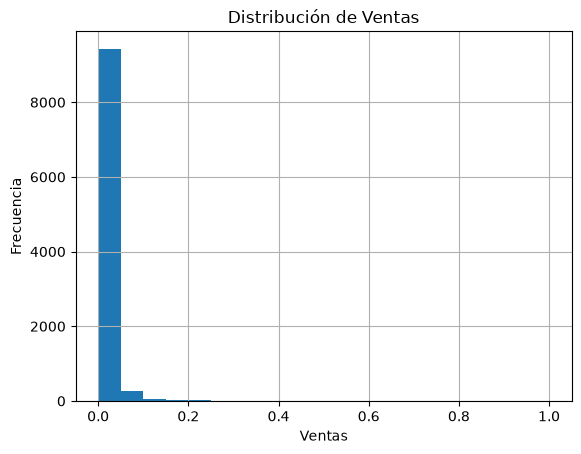

In [48]:
df["Sales"].hist(
    bins=20
)

plt.title("Distribución de Ventas")
plt.xlabel("Ventas")
plt.ylabel("Frecuencia")

plt.show()

Codificar la columna categoria

In [50]:
df["Segment"] = df["Segment"].map({
    "Consumer": 0,
    "Corporate": 1,
    "Home Office": 2
})

Seleccionar el subconjunto de columnas

In [51]:
datos = df[
    ["Sales", "Segment", "Quantity" if "Quantity" in df.columns else "Postal Code", "Category"]
]

Revisar nulos y tipos

In [52]:
print("TIPOS DE DATOS")
print(datos.dtypes)
print("\nVALORES NULOS")
print(datos.isnull().sum())
print("\nPRIMEROS REGISTROS")
print(datos.head())

TIPOS DE DATOS
Sales          float64
Segment          int64
Postal Code    float64
Category           str
dtype: object

VALORES NULOS
Sales           0
Segment         0
Postal Code    11
Category        0
dtype: int64

PRIMEROS REGISTROS
      Sales  Segment  Postal Code         Category
0  0.011552        0      42420.0        Furniture
1  0.032313        0      42420.0        Furniture
2  0.000626        1      90036.0  Office Supplies
3  0.042280        0      33311.0        Furniture
4  0.000968        0      33311.0  Office Supplies


Rellenar mulos

In [53]:
df["Sales"] = df["Sales"].fillna(df["Sales"].median())

Matrix de coseno

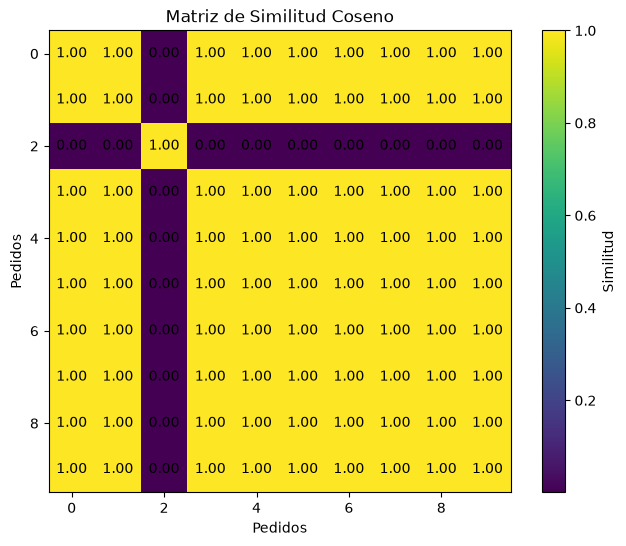

In [54]:
from sklearn.metrics.pairwise import cosine_similarity

datos_num = df[["Sales", "Segment"]].select_dtypes(include="number")

similitud = cosine_similarity(datos_num.iloc[:10])

plt.figure(figsize=(8,6))
plt.imshow(similitud)
plt.colorbar(label="Similitud")
for i in range(similitud.shape[0]):
    for j in range(similitud.shape[1]):
        plt.text(j, i, f"{similitud[i,j]:.2f}", ha="center", va="center")
plt.title("Matriz de Similitud Coseno")
plt.xlabel("Pedidos")
plt.ylabel("Pedidos")
plt.show()